# Fasi del progetto:

1. **Caricamento e Analisi Preliminare dei Dati**  
   - Caricamento del dataset, trasformazione in DataFrame.  
   - **EDA**: Analisi descrittiva, visiva e statistica, esplorazione di distribuzioni, correlazioni, e dati mancanti.

2. **Preparazione dei Dati**  
   - Divisione in set di addestramento e test.  
   - Visualizzazione outlier, distribuzioni e applicazione di trasformazioni come la standardizzazione.

3. **Analisi delle Relazioni tra le Variabili**  
   - Valutazione dell'effetto della standardizzazione, esplorazione delle multicollinearità, analisi dell'importanza delle variabili tramite metodi come la Random Forest.

4. **Ottimizzazione del Modello**  
   - Ricerca dei migliori iperparametri tramite RandomizedSearchCV per il modello Random Forest.

5. **Valutazione e Resoconto Finale**  
   - Creazione di report sui risultati del modello, inclusi metriche di performance e analisi finale sui risultati del test set.

In [1]:
import math
import inspect
import numpy as np
import pandas as pd
from time import time
import seaborn as sns
from tabulate import tabulate
from scipy.stats import randint
import matplotlib.pyplot as plt
from itertools import zip_longest
from sklearn.datasets import load_wine
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from statsmodels.tools.tools import add_constant
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression, LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score, cross_val_predict

### 1. **Caricamento del dataset e trasformazione in DataFrame**

Il primo passo consiste nel caricare il dataset e convertirlo in un DataFrame di `pandas`, un formato tabellare che semplifica la gestione e l'analisi dei dati. Questa operazione ci consente di lavorare con i dati in modo più intuitivo e di esplorarli facilmente per comprendere la struttura del dataset, incluse le variabili presenti e il tipo di informazioni contenute. Dopo aver caricato il dataset, posso accedere direttamente alle caratteristiche e alle etichette per prepararmi alla fase successiva di analisi.

In [2]:
# Carica il dataset wine
# Il dataset 'wine' è un dizionario che contiene diversi array e informazioni utili per l'analisi dei vini
wine = load_wine()

# Stampa le chiavi del dizionario wine per ispezionare la struttura
# Il dizionario 'wine' contiene diverse chiavi che fanno riferimento ai dati (features e target) e altre informazioni utili (nomi delle caratteristiche, descrizione, etc.)
# Questo passaggio aiuta a capire la struttura del dataset e a verificare quali informazioni sono disponibili.
for chiave in wine:
    print(chiave)
print()

# Creazione del DataFrame con le caratteristiche e il target
# Creo un DataFrame pandas contenente le caratteristiche del vino (features) come colonne e il target (classi del vino) come una colonna aggiuntiva
# Questo rende più facile lavorare con i dati, esplorarli e applicare operazioni di analisi in modo tabellare.
df = pd.DataFrame(data=wine['data'], columns=wine['feature_names']).assign(target=wine['target'])

# Visualizza le prime righe del DataFrame
# Visualizzare le prime righe del DataFrame è un passaggio iniziale fondamentale per confermare che i dati siano stati caricati correttamente
# e per ottenere una panoramica rapida delle prime osservazioni e della struttura del dataset.
# Viene utilizzato `to_string()` per visualizzare tutte le colonne del DataFrame in un formato leggibile,
# poiché pandas, di default, potrebbe omettere o suddividere le colonne su più righe (con accapi) se il numero di colonne è elevato.
print(df.head().to_string())

data
target
frame
target_names
DESCR
feature_names

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  od280/od315_of_diluted_wines  proline  target
0    14.23        1.71  2.43               15.6      127.0           2.80        3.06                  0.28             2.29             5.64  1.04                          3.92   1065.0       0
1    13.20        1.78  2.14               11.2      100.0           2.65        2.76                  0.26             1.28             4.38  1.05                          3.40   1050.0       0
2    13.16        2.36  2.67               18.6      101.0           2.80        3.24                  0.30             2.81             5.68  1.03                          3.17   1185.0       0
3    14.37        1.95  2.50               16.8      113.0           3.85        3.49                  0.24             2.18             7.80  0.86                     


### 2. **Analisi preliminare dei dati**

Una volta che i dati sono stati caricati e organizzati in un DataFrame, è fondamentale eseguire una serie di verifiche preliminari. In particolare, controllo la presenza di valori mancanti e duplicati. I valori nulli possono compromettere l'accuratezza del modello, quindi è essenziale gestirli in modo appropriato (rimuovendoli o sostituendoli). Inoltre, la presenza di duplicati potrebbe causare una distorsione dei risultati, quindi è necessario eliminarli per evitare che influiscano negativamente sulle performance del modello.

In [3]:
# Analizzo le varie informazioni del df
# Il metodo `info()` fornisce informazioni sulle colonne del DataFrame, come il tipo di dati e la presenza di valori nulli.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [4]:
# Verifica che non ci siano duplicati
# Verifico la presenza di righe duplicate. I duplicati nei dati possono influire negativamente sull'addestramento del modello.
# Se ce ne sono, dovrebbero essere rimossi.
df.duplicated().sum()

0

In [5]:
# Controllo che per ogni colonna se ci sono e la quantità di valori nan
# Verifico la presenza di valori nulli (NaN) nelle colonne. Se ci sono, bisogna decidere come gestirli (imputazione, rimozione, etc.)
df.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

### 3. **Divisione del dataset in set di addestramento e di test**

Per evitare il rischio di overfitting e garantire che il modello sia in grado di generalizzare correttamente sui dati nuovi, separo il dataset in due set: uno per l'addestramento e uno per il test. Utilizzando la funzione train_test_split, divido i dati in un set di addestramento (80%) e un set di test (20%). Questa divisione è una pratica standard per garantire che il modello venga allenato su una parte dei dati e testato su una porzione separata che non ha visto durante l'addestramento, permettendo di valutare la capacità di generalizzazione del modello.

Ho utilizzato stratify=y nel train_test_split per mantenere la distribuzione delle classi proporzionale in entrambi i set, evitando bias derivanti da un campionamento sbilanciato. Inoltre, ho verificato visivamente il bilanciamento delle classi per assicurarmi che fosse molto lieve e che non ci fossero discrepanze significative tra i set di addestramento e test.

**Sbilanciamento Basso**: Discrepanza inferiore al 10% (0% - 10%).  
**Sbilanciamento Medio**: Discrepanza tra il 10% e il 20% (10% - 20%).  
**Sbilanciamento Alto**: Discrepanza superiore al 20% (20% e oltre).

Per la scelta delle soglie mi sono bassato su https://developers.google.com/machine-learning/crash-course/overfitting/imbalanced-datasets?hl=it, dove riporta questa tabella  

Percentuale della classe minoritaria/Grado di squilibrio  
20–40%	Moderato  
1–20%	Moderato  
<1%	Estremo

Supponiamo un dataset con 3 classi. La differenza di percentuale tra la classe più grande e quella più piccola ti dice quanto è forte lo sbilanciamento.
Usiamo questa formula:
    Sbilanciamento (%) = Percentuale della classe maggioritaria − Percentuale della classe minoritaria

Bilanciato (33% - 33% - 33%)  
→ differenze minime → differenza <10%  
→ Sbilanciamento basso  

Moderatamente sbilanciato (60% - 25% - 15%)  
→ classe maggioritaria = 60%, minoritaria = 15%  
→ differenza = 45%  
→ Sbilanciamento alto  

Estremamente sbilanciato (90% - 9% - 1%)  
→ differenza = 89%  
→ Sbilanciamento estremo  

Di conseguenza avremo questo tipo di soglie (in base alla differenza tra % maggioritaria e minoritaria):  
Differenza percentuale (maggioritaria - minoritaria)	Grado di squilibrio  
< 10%	Basso  
10% – 30%	Medio  
30% – 60%	Alto  
60% o più	Estremo

In [6]:
# Impostiamo il seed del generatore di numeri casuali di NumPy a 0
# Questo garantisce che i numeri casuali generati siano gli stessi ad ogni esecuzione
np.random.seed(0)

# Carica i dati e le etichette
# La variabile `feature` contiene tutte le colonne delle caratteristiche (variabili indipendenti) del dataset,
# tranne l'ultima colonna che rappresenta il target (etichetta). Queste caratteristiche sono quelle che il modello userà per fare le previsioni.
feature = df.drop(columns=['target'])  # Le caratteristiche di ciascun vino (tutte le colonne tranne l'ultima)

# La variabile `target` contiene la colonna dell'etichetta, che rappresenta le classi a cui appartengono i campioni di vino.
# Questo target sarà ciò che il modello dovrà predire in base alle caratteristiche fornite.
target = df['target']  # Il target (classi del vino, ultima colonna)

# Assegno i dati alle variabili `X` e `y`
X = feature  # `X` contiene le caratteristiche che il modello userà per fare le previsioni
y = target   # `y` contiene il target, che sono le etichette (classi) che il modello deve prevedere

# Suddividi i dati in training e test
# Uso `train_test_split` per separare il dataset in set di addestramento e test (80%/20%). Questo è cruciale per la validazione del modello.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
y_train.name = y.name
y_test.name = y.name

# Verifica il nome della colonna di y_train e y_test
#print(f"Nome di y_train: {y_train.name}")
#print(f"Nome di y_test: {y_test.name}")

def calcola_distribuzione_e_sbilanciamento(y_list):
    """
    Calcola e stampa la distribuzione delle classi, lo sbilanciamento in percentuale, la somma dei conteggi
    e la somma delle percentuali per ciascun set, iterando su tutte le colonne (serie) nella lista di input.

    :param y_list: Lista di Serie o DataFrame da cui calcolare la distribuzione delle classi e lo sbilanciamento.
    """
    for i, y in enumerate(y_list):
        print(f"Elaborazione della variabile {i + 1}: {y.name if hasattr(y, 'name') else f'Serie {i + 1}'}")

        # Calcola la distribuzione delle classi
        distribuzione = y.value_counts()
        distribuzione_percentuale = (distribuzione / len(y) * 100).round(2)

        # Calcolo dello sbilanciamento come differenza tra la percentuale della classe più grande e quella più piccola
        sbilanciamento = distribuzione_percentuale.max() - distribuzione_percentuale.min()

        # Calcola la somma dei conteggi e delle percentuali
        somma_conteggi = distribuzione.sum()
        somma_percentuali = distribuzione_percentuale.sum()

        # Stampa la distribuzione e lo sbilanciamento per ciascuna serie
        print("Distribuzione delle classi (classe X: conteggio | percentuale):")
        for classe, conteggio in distribuzione.items():
            print(f"Classe {classe}: {conteggio} | {distribuzione_percentuale[classe]:.2f}%")

        print(f"Somma dei conteggi: {somma_conteggi}")
        print(f"Somma delle percentuali: {somma_percentuali:.2f}%")
        print(f"Sbilanciamento tra classe maggioritaria e minoritaria: {sbilanciamento:.2f}%\n")

# Chiamata alla funzione con una lista di variabili
calcola_distribuzione_e_sbilanciamento([y_train])#, y_test])

Elaborazione della variabile 1: target
Distribuzione delle classi (classe X: conteggio | percentuale):
Classe 1: 57 | 40.14%
Classe 0: 47 | 33.10%
Classe 2: 38 | 26.76%
Somma dei conteggi: 142
Somma delle percentuali: 100.00%
Sbilanciamento tra classe maggioritaria e minoritaria: 13.38%



### 4. **Analisi esplorativa dei dati (EDA)**

Per capire meglio la distribuzione e le relazioni tra le variabili, eseguo un'analisi esplorativa dei dati. Inizio con il metodo `describe()` per ottenere statistiche descrittive sulle variabili numeriche, come la media, la deviazione standard, i valori minimi e massimi, ecc. Successivamente, creo una matrice di correlazione per esplorare le relazioni tra le variabili. La matrice di correlazione aiuta a identificare variabili che sono fortemente correlate tra loro, il che potrebbe suggerire la possibilità di rimuovere o combinare alcune variabili per semplificare il modello. Creo anche un grafico di correlazione per visualizzare meglio queste relazioni.

In [8]:
# Descrizione del DataFrame con numeri arrotondati a due decimali
X_train.describe().round(2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,142.00,142.00,142.00,142.00,142.00,142.00,142.00,142.00,142.00,142.00,142.00,142.00,142.00
mean,12.97,2.34,2.36,19.63,99.63,2.27,1.99,0.36,1.60,4.99,0.95,2.61,739.48
std,0.80,1.10,0.27,3.38,14.94,0.62,0.95,0.12,0.58,2.33,0.23,0.69,301.50
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.42,1.28,0.48,1.27,278.00
25%,12.37,1.61,2.20,17.20,88.00,1.70,1.23,0.27,1.25,3.06,0.78,1.97,496.25
50%,13.01,1.81,2.36,19.50,97.00,2.34,2.13,0.34,1.56,4.64,0.96,2.78,673.50
75%,13.56,3.17,2.56,21.50,107.75,2.80,2.78,0.43,1.95,6.18,1.09,3.16,981.25
max,14.83,5.80,3.22,30.00,162.00,3.88,3.74,0.63,3.58,13.00,1.71,3.92,1515.00


In [9]:
# Calcola la matrice di correlazione per il DataFrame X_train.
# La correlazione misura quanto fortemente due variabili sono linearmente correlate tra loro.
corr_matrix = X_train.corr().round(2)

# Stampa la matrice di correlazione come stringa completa, con valori arrotondati a 2 decimali.
# Il metodo .to_string() è usato per evitare il troncamento del DataFrame in fase di stampa.
print(corr_matrix.to_string())

                              alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  od280/od315_of_diluted_wines  proline
alcohol                          1.00        0.10  0.25              -0.30       0.28           0.31        0.27                 -0.13             0.09             0.54 -0.09                          0.08     0.62
malic_acid                       0.10        1.00  0.14               0.23      -0.03          -0.31       -0.38                  0.24            -0.22             0.23 -0.57                         -0.37    -0.20
ash                              0.25        0.14  1.00               0.44       0.25           0.15        0.10                  0.16             0.02             0.25 -0.06                         -0.01     0.25
alcalinity_of_ash               -0.30        0.23  0.44               1.00      -0.10          -0.29       -0.36                  0.34          

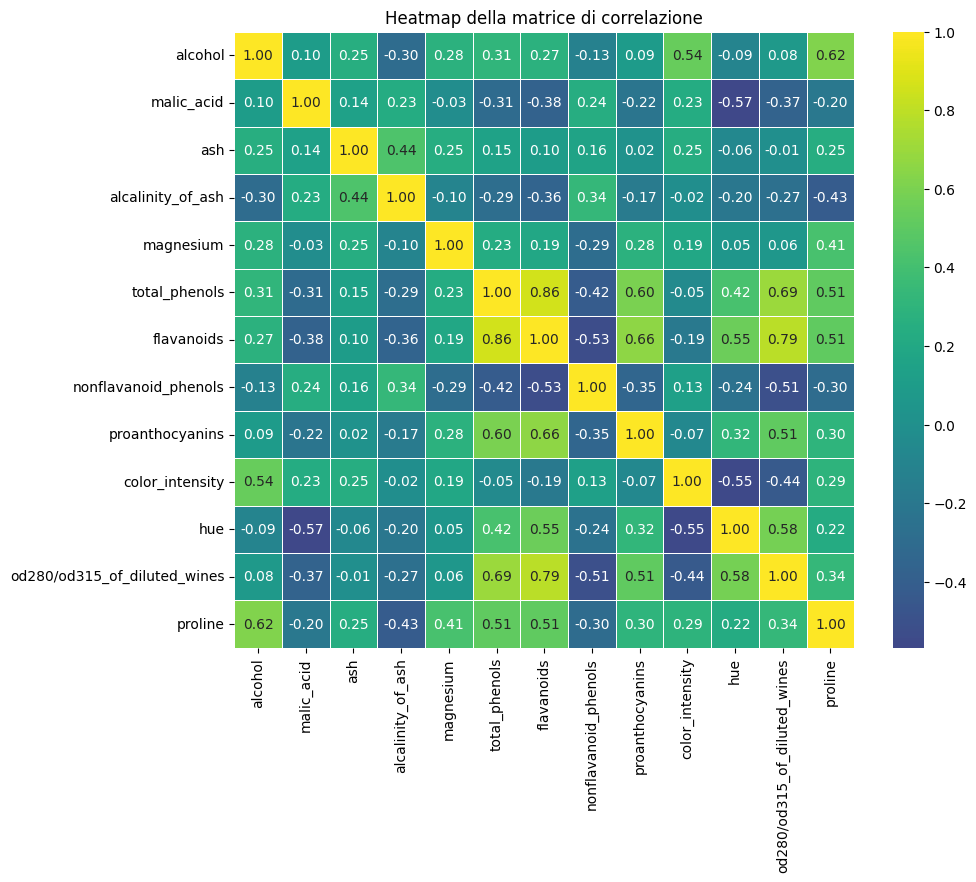

In [10]:
# Calcola la matrice di correlazione tra le feature del DataFrame X_train
corr_matrix = X_train.corr()

# Imposta la dimensione della figura (10 pollici di larghezza x 8 di altezza)
plt.figure(figsize=(10, 8))

# Crea la heatmap:
# - corr_matrix: la matrice da visualizzare
# - annot=True: mostra i valori numerici all'interno delle celle
# - cmap='viridis': specifica la palette di colori (puoi usare anche 'coolwarm', 'Blues', ecc.)
# - fmt=".2f": formatta i numeri con due decimali
# - linewidths=.5: imposta lo spessore delle linee che separano le celle
# - center=0: imposta lo zero come valore centrale nella scala dei colori (utile se i dati hanno sia correlazioni positive che negative)
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5, center=0)

# Imposta il titolo del grafico
plt.title("Heatmap della matrice di correlazione")

# Mostra la figura
plt.show()

## Analisi della matrice di correlazione:

Nel grafico di **correlazione** possiamo osservare chiaramente le relazioni tra le variabili del nostro dataset. Le celle scure indicano una forte correlazione tra le variabili, mentre i colori chiari suggeriscono una correlazione debole. In particolare, ci concentriamo sulle **correlazioni superiori a 0.65**:

1. **flavanoids** e **total_phenols**: 0.86
2. **flavanoids** e **od280/od315_of_diluted_wines**: 0.79
3. **flavanoids** e **proline**: 0.79
4. **total_phenols** e **od280/od315_of_diluted_wines**: 0.69
5. **total_phenols** e **proline**: 0.69
6. **proanthocyanins** e **flavanoids** : 0.66

Queste variabili sono moderatamente o fortemente correlate tra loro, indicando che potrebbero esserci delle **ridondanze** nei dati, che potrebbero influire negativamente sull'accuratezza di alcuni modelli predittivi.

### 5. **Analisi della distribuzione e degli outliers tramite Box Plot**

Per esaminare ulteriormente la distribuzione dei dati e verificare la presenza di outliers, creo un box plot per ogni variabile target. I box plot sono utili per identificare visivamente i valori anomali (outliers) che potrebbero influenzare negativamente la performance del modello. Gli outliers sono valori estremi che si trovano al di fuori del range interquartile, e la loro gestione (ad esempio, rimuovendoli o trattandoli in modo diverso) può migliorare la qualità del modello. In questo caso non applicheremo nessuna modifica.

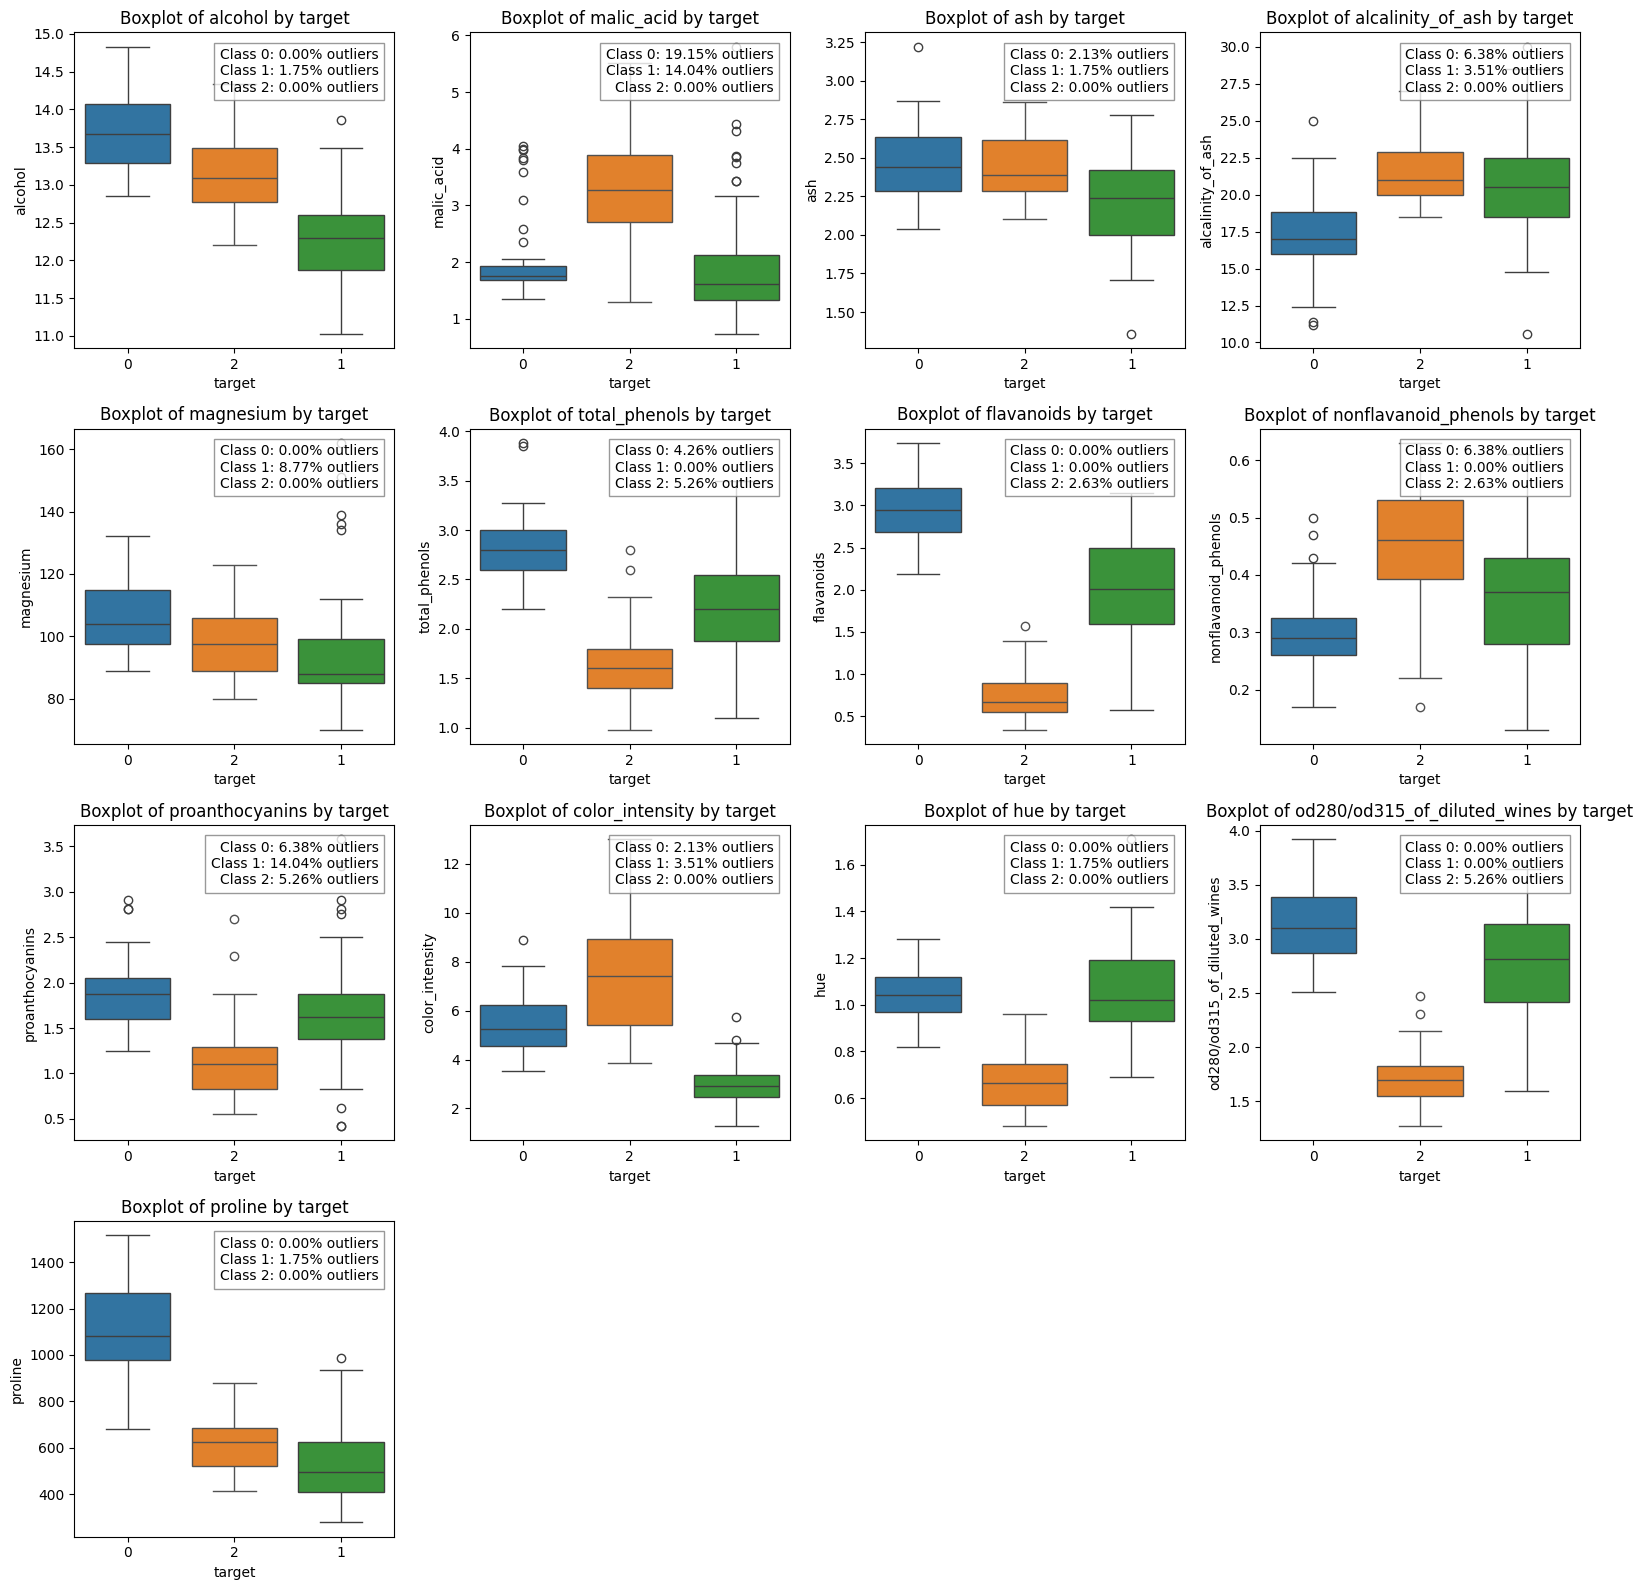

Tabella delle percentuali di outlier per ogni feature, raggruppate per feature:
                         Feature  Class_0  Class_1  Class_2
0                        alcohol     0.00     1.75     0.00
1                     malic_acid    19.15    14.04     0.00
2                            ash     2.13     1.75     0.00
3              alcalinity_of_ash     6.38     3.51     0.00
4                      magnesium     0.00     8.77     0.00
5                  total_phenols     4.26     0.00     5.26
6                     flavanoids     0.00     0.00     2.63
7           nonflavanoid_phenols     6.38     0.00     2.63
8                proanthocyanins     6.38    14.04     5.26
9                color_intensity     2.13     3.51     0.00
10                           hue     0.00     1.75     0.00
11  od280/od315_of_diluted_wines     0.00     0.00     5.26
12                       proline     0.00     1.75     0.00


In [43]:
def detect_outliers_improved(X, y):
    """
    Analizza e visualizza gli outlier per ciascuna feature numerica, distinta per ciascuna classe del target.

    Parametri:
    - X: DataFrame contenente le feature numeriche
    - y: Serie contenente il target

    Restituisce:
    - DataFrame con le percentuali di outlier per feature e per classe
    """

    # Controllo se X o y sono vuoti e solleva un errore se lo sono
    if X.empty or y.empty:
        raise ValueError("X o y sono vuoti. Assicurati di fornire dati validi.")

    # Crea una copia di X e aggiunge la colonna target per analizzare le classi
    df = X.copy()
    df['target'] = y.values

    # Dizionario per salvare le percentuali di outlier per ogni feature e classe
    outliers = {}

    # Seleziona solo le colonne numeriche (escludendo il target)
    num_columns = df.select_dtypes(include=[np.number]).columns.drop('target', errors='ignore')
    n = len(num_columns)  # Numero di colonne numeriche

    # Imposta la griglia dei subplot per i boxplot (max 4 colonne per visualizzazione)
    ncols = min(4, n)  # Numero massimo di colonne per ogni riga
    nrows = (n + ncols - 1) // ncols  # Calcola il numero di righe necessarie
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()  # Appiattisce la griglia per un facile accesso ai singoli assi

    # Loop per ogni colonna numerica
    for i, column in enumerate(num_columns):
        ax = axes[i]  # Seleziona il subplot corrente

        # Loop per ogni classe del target
        for target_value in df['target'].unique():
            df_class = df[df['target'] == target_value]  # Filtra i dati per la classe corrente

            # Se la classe non ha dati, la saltiamo
            if len(df_class) == 0:
                continue

            # Calcola il primo e terzo quartile, e l'intervallo interquartile (IQR)
            Q1 = df_class[column].quantile(0.25)
            Q3 = df_class[column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR  # Limite inferiore per gli outlier
            upper_bound = Q3 + 1.5 * IQR  # Limite superiore per gli outlier

            # Identifica gli outlier: valori che superano i limiti calcolati
            is_outlier = (df_class[column] < lower_bound) | (df_class[column] > upper_bound)

            # Calcola la percentuale di outlier per la classe corrente
            outlier_percentage = is_outlier.sum() / len(df_class) * 100 if len(df_class) > 0 else 0
            outliers[f"{column}_class_{target_value}"] = outlier_percentage

            # Crea un boxplot della feature per la classe corrente
            sns.boxplot(x=df_class['target'], y=df_class[column], ax=axes[i])
            #sns.violinplot(x=df_class['target'], y=df_class[column], ax=ax, inner="box")
            axes[i].set_title(f'Boxplot of {column} by target')

        # Prepara il testo con le percentuali di outlier per ciascuna classe
        info_text = "\n".join(
            [f"Class {val}: {outliers[f'{column}_class_{val}']:.2f}% outliers"
             for val in sorted(df['target'].unique())
             if not np.isnan(outliers[f"{column}_class_{val}"])]
        )

        # Se il testo con le percentuali di outlier è disponibile, lo mostra nel grafico
        if info_text:
            ax.text(
                0.95, 0.95, info_text,  # Posizione del testo nel grafico
                transform=ax.transAxes,  # Riferimento alla traslazione in coordinate dell'asse
                ha='right', va='top',  # Allineamento del testo
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')  # Background del testo
            )

    # Rimuove i subplot non utilizzati, se ce ne sono
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Ottimizza la disposizione dei grafici
    plt.tight_layout()
    plt.show()

    # Costruisce un dizionario con le percentuali di outlier per ogni feature e classe
    outliers_data = {}
    for column in num_columns:
        outliers_data[column] = {}
        for target_value in sorted(df['target'].unique()):
            outlier_percentage = outliers.get(f"{column}_class_{target_value}", 0)
            outliers_data[column][f"Class_{target_value}"] = outlier_percentage

    # Converte il dizionario in un DataFrame per una visualizzazione più facile
    outliers_df = pd.DataFrame(outliers_data).T  # Le feature come righe
    outliers_df = outliers_df.reset_index().rename(columns={"index": "Feature"})  # Rinomina la colonna dell'indice

    return outliers_df  # Ritorna il DataFrame con le percentuali di outlier per ogni feature

# Esegui la funzione per ottenere le percentuali di outlier su X_train
outliers_df = detect_outliers_improved(X_train, y_train)

# Stampa il DataFrame con le percentuali di outlier per ciascuna feature e classe
print("Tabella delle percentuali di outlier per ogni feature, raggruppate per feature:")
print(outliers_df.round(2))  # Arrotonda a due decimali per maggiore leggibilità

### 6. **Standardizzazione dei dati con StandardScaler**

La standardizzazione è utile per modelli sensibili alla scala dei dati, come la regressione logistica, knn o le reti neurali, per evitare che variabili con scale diverse influenzino l'addestramento.

In [36]:
# Inizializza lo standardizzatore
scaler = StandardScaler()

# Calcola i parametri di scaling su X_train e applica la trasformazione
X_train_scaled_np = scaler.fit_transform(X_train)

# Applica la stessa trasformazione a X_test utilizzando i parametri di X_train
X_test_scaled_np = scaler.transform(X_test)

# Converte gli array scalati in DataFrame, mantenendo i nomi originali delle colonne
X_train_scaled = pd.DataFrame(X_train_scaled_np, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled_np, columns=X_test.columns)

# Reimposta l'indice dei DataFrame scalati per evitare incongruenze
X_train_scaled = X_train_scaled.reset_index(drop=True)
X_test_scaled = X_test_scaled.reset_index(drop=True)

# Reimposta l'indice anche per i target y_train e y_test
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

## Eseguo uno spotcheck tra il training set completo non scalato e scalato

In [37]:
np.random.seed(0)
# Funzione per eseguire la cross-validation e restituire i risultati
def rapid_spot(X_data_input, y_train):
    """
    Esegue la valutazione dei modelli con cross-validation e restituisce i risultati in un DataFrame.

    Parametri:
    - X_data_input: Un singolo set di dati o una lista di set di dati
    - y_train: Target di addestramento

    Restituisce:
    - Un dizionario contenente DataFrame con i risultati per ciascun set di dati.
    """
    # Se è un singolo dataset, lo trasformiamo in lista
    if not isinstance(X_data_input, list):
        X_data_list = [X_data_input]
    else:
        X_data_list = X_data_input

    modelli = {
        'LogisticRegression': LogisticRegression(max_iter=10000),
        'RandomForestClassifier': RandomForestClassifier(n_jobs=-1),
        'KNeighborsClassifier': KNeighborsClassifier(),
        'LinearRegression': LinearRegression()
    }

    risultati_completi = {}

    frame = inspect.currentframe().f_back
    caller_locals = frame.f_locals
    nome_dati = [name for name, value in caller_locals.items() if id(value) in [id(X) for X in X_data_list]]

    # In caso manchino dei nomi (es: lista creata inline), generiamo nomi fallback
    while len(nome_dati) < len(X_data_list):
        nome_dati.append(f"Dataset_{len(nome_dati)+1}")

    for X_dat, nome_dato in zip(X_data_list, nome_dati):
        print(f'\nValutazioni per {nome_dato}:')

        risultati_modelli = []

        for nome_modello, modello in modelli.items():
            seed = 7
            cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

            risultati = cross_val_score(modello, X_dat, y_train, cv=cv)
            risultati_modelli.append(risultati.mean())

            print(f'{nome_modello}: Accuratezza media: {risultati.mean()}')

        risultati_completi[nome_dato] = pd.DataFrame({
            'Modello': modelli.keys(),
            'Accuratezza media': risultati_modelli
        })

    return risultati_completi

# Chiamata della funzione con i dati
risultati_completi = rapid_spot([X_train, X_train_scaled], y_train) # X_train_scaled_mutual_selected,  X_train_scaled_selected_chi2,

# Mostra le tabelle per ogni set di dati
for nome_dato, tabella in risultati_completi.items():
    print(f'\nTabella dei risultati per {nome_dato}:')
    print(tabella)


Valutazioni per X_train:
LogisticRegression: Accuratezza media: 0.971904761904762
RandomForestClassifier: Accuratezza media: 0.9785714285714286
KNeighborsClassifier: Accuratezza media: 0.6828571428571427
LinearRegression: Accuratezza media: 0.8870491080449072

Valutazioni per X_train_scaled:
LogisticRegression: Accuratezza media: 0.9785714285714286
RandomForestClassifier: Accuratezza media: 0.9785714285714286
KNeighborsClassifier: Accuratezza media: 0.9504761904761905
LinearRegression: Accuratezza media: 0.8870491080449074

Tabella dei risultati per X_train:
                  Modello  Accuratezza media
0      LogisticRegression           0.971905
1  RandomForestClassifier           0.978571
2    KNeighborsClassifier           0.682857
3        LinearRegression           0.887049

Tabella dei risultati per X_train_scaled:
                  Modello  Accuratezza media
0      LogisticRegression           0.978571
1  RandomForestClassifier           0.978571
2    KNeighborsClassifier      

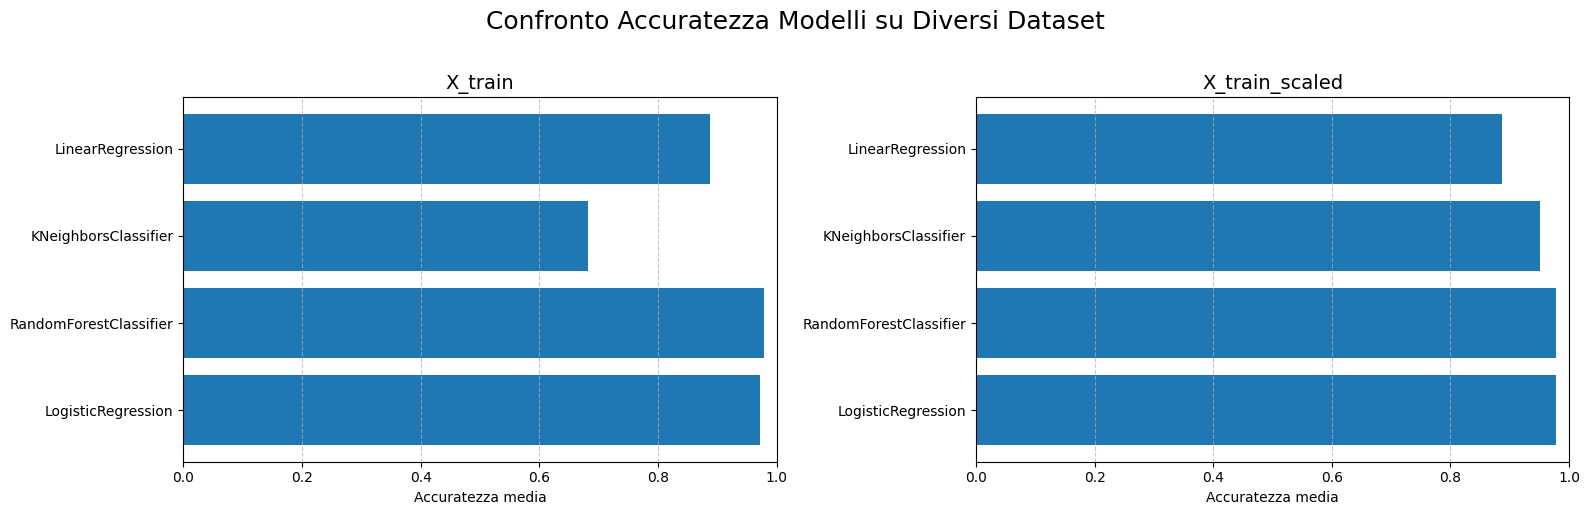

In [14]:
# Numero di dataset da plottare
n_datasets = len(risultati_completi)

# Calcola il numero di righe e colonne per la griglia
n_cols = 2  # puoi modificare se preferisci più o meno colonne
n_rows = math.ceil(n_datasets / n_cols)

# Crea la figura e gli assi
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 5 * n_rows), squeeze=False)

# Itera su ogni set di dati e assegna il subplot
for idx, (nome_dato, tabella) in enumerate(risultati_completi.items()):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row][col]
    
    ax.barh(tabella['Modello'], tabella['Accuratezza media'])#, color='skyblue')
    ax.set_title(f'{nome_dato}', fontsize=14)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Accuratezza media')
    ax.grid(axis='x', linestyle='--', alpha=0.7)

# Rimuovi gli assi vuoti (se ci sono)
for idx in range(n_datasets, n_rows * n_cols):
    fig.delaxes(axes[idx // n_cols][idx % n_cols])

# Aggiusta layout e titolo generale
plt.suptitle('Confronto Accuratezza Modelli su Diversi Dataset', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

La valutazione dei modelli eseguita sul set `X_train_scaled` ha dato risultati davvero soddisfacenti. In particolare, sia la **Logistic Regression** che il **Random Forest Classifier** hanno raggiunto un'accuratezza media molto elevata, intorno al **97.86%**, dimostrando un'ottima capacità di predizione. Anche il **KNeighbors Classifier**, che solitamente è molto sensibile alla scala dei dati, ha performato molto bene, arrivando a circa il **95%** di accuratezza. Infine, anche se meno sofisticata, la **Linear Regression** ha mantenuto risultati più che accettabili, con un’accuratezza media attorno all’**88.7%**.

Tuttavia, per capire davvero l’efficacia di questi modelli, vale la pena confrontare queste performance con quelle ottenute sul set originale `X_train`, cioè **senza scaling**. È proprio da questo confronto che emergono differenze interessanti.

Nel caso dei dati non scalati, la **Logistic Regression** ha ottenuto un'accuratezza leggermente più bassa rispetto alla versione scalata e ha mostrato dei **warning di convergenza**, eliminati aumentando il numero di iterazioni (max_iter=10000). Questo non sorprende: i modelli lineari, come la Logistic Regression, beneficiano notevolmente del fatto che le variabili siano normalizzate, perché operano attraverso ottimizzazioni che possono diventare instabili se le scale delle feature sono molto diverse tra loro.

Il **Random Forest**, invece, si è dimostrato ancora una volta un modello estremamente robusto: ha mantenuto quasi lo stesso livello di accuratezza sia sui dati scalati che non scalati. Questo è coerente con la natura di Random Forest, che non si basa su distanze o coefficienti ma su suddivisioni condizionali, rendendolo insensibile alla scala delle variabili. È uno dei motivi per cui è così amato nei contesti di machine learning pratico: funziona bene anche se il preprocessing non è perfetto.

Il **KNeighbors Classifier**, al contrario, ha evidenziato una dipendenza molto forte dalla scala dei dati. Sui dati non scalati, infatti, l'accuratezza è crollata a circa il **68%**, mentre con la normalizzazione è balzata a **95%**. Questo comportamento è spiegabile facilmente: KNN si basa su una misura di distanza (tipicamente euclidea), e se una feature ha un range molto più ampio delle altre, finisce per dominare completamente la distanza, rendendo il modello poco affidabile. La scaling è quindi essenziale per farlo funzionare bene.

Infine, la **Linear Regression** ha mantenuto più o meno lo stesso livello di accuratezza in entrambi i casi. Tuttavia, questo non significa che sia del tutto insensibile alla scala dei dati. Anche se la metrica finale sembra stabile, la **multicollinearità** e le diverse scale tra le feature possono rendere i coefficienti instabili e difficili da interpretare. In modelli lineari, interpretabilità e stabilità vanno spesso di pari passo, e la normalizzazione aiuta a garantire entrambe.

In sintesi, quello che emerge con chiarezza è che **la scaling impatta i modelli in maniera molto diversa**, a seconda del loro funzionamento interno. I modelli basati su distanze (come KNN) o su ottimizzazioni numeriche (come Logistic Regression) migliorano sensibilmente con la normalizzazione, mentre modelli più “robusti” come Random Forest sono meno influenzati.

Un aspetto particolarmente interessante è che, a prescindere dal modello e dalla presenza o meno di scaling, quasi tutti (tranne KNN su dati non scalati) hanno ottenuto **buoni livelli di accuratezza**. Questo suggerisce qualcosa di molto importante: **il dataset è davvero ben fatto**.

Un buon dataset, infatti, è quello in cui esiste una relazione chiara tra le feature e il target, dove i dati sono puliti, privi di valori mancanti o outlier estremi, bilanciati tra le classi, e le variabili predittive sono informative. In pratica, contiene **più segnale che rumore**, il che facilita notevolmente il lavoro dei modelli.

Quindi, anche se modelli come Random Forest sono più complessi e versatili, in questo caso anche approcci più semplici come la Linear Regression riescono a performare bene. Questo ci porta a una riflessione fondamentale nel mondo del machine learning:

> **Un buon modello nasce sempre da un buon dataset.**

In altre parole, possiamo scegliere l’algoritmo migliore, ma se i dati non sono curati, puliti e strutturati correttamente, nessun modello potrà fare miracoli. Al contrario, quando i dati sono di qualità, anche modelli semplici possono raggiungere risultati eccellenti.

## Analisi della multicollinearità precedentemente teorizzata.

In [ ]:
# === Funzione per calcolare il VIF ===
def calcola_vif(X):
    X_const = add_constant(X)
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_const.columns
    vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
    return vif_data

# === Calcolo VIF (usa dati NON scalati) ===
vif_result = calcola_vif(X_train)

print("\nVIF per tutte le feature:")
print(vif_result.sort_values(by="VIF", ascending=False))

# === Rimuovi feature con VIF > 10 (escludendo 'const') ===
features_to_remove = vif_result[(vif_result['VIF'] > 10) & (vif_result['Feature'] != 'const')]['Feature'].tolist()

# === Applichiamo la rimozione al dataset GIA' scalato ===
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_train_scaled_reduced = X_train_scaled_df.drop(columns=features_to_remove)

# === Cross-validation senza pipeline perché i dati sono già scalati ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = LogisticRegression()

scores_full = cross_val_score(model, X_train_scaled_df, y_train, cv=skf, scoring='accuracy')
scores_reduced = cross_val_score(model, X_train_scaled_reduced, y_train, cv=skf, scoring='accuracy')

# === Risultati ===
print(f"\nAccuratezza media (modello completo): {scores_full.mean():.4f}")# ± {scores_full.std():.4f}")
print(f"Accuratezza media (senza feature collineari): {scores_reduced.mean():.4f}")# ± {scores_reduced.std():.4f}")

if scores_reduced.mean() > scores_full.mean():
    print("Rimuovere le feature con multicollinearità ha **migliorato** le performance.")
elif scores_reduced.mean() < scores_full.mean():
    print("Rimuovere le feature con multicollinearità ha **peggiorato** le performance.")
else:
    print("Le performance **non sono cambiate** dopo la rimozione.")

if features_to_remove:
    # === Mostra le feature rimosse con i loro VIF ===
    print("\nFeature rimosse a causa di VIF > 10:")
    print(vif_result[vif_result['Feature'].isin(features_to_remove)][['Feature', 'VIF']])
else:
    print("\nNessuna feature rimossa: tutte avevano VIF < 10.")



VIF per tutte le feature:
                         Feature         VIF
0                          const  667.237712
7                     flavanoids    7.678239
6                  total_phenols    4.393180
12  od280/od315_of_diluted_wines    3.868565
10               color_intensity    3.105380
11                           hue    2.774456
13                       proline    2.744944
1                        alcohol    2.434395
4              alcalinity_of_ash    2.229348
3                            ash    2.133519
9                proanthocyanins    2.087980
8           nonflavanoid_phenols    1.837355
2                     malic_acid    1.649677
5                      magnesium    1.534220

Accuratezza media (modello completo): 0.9791
Accuratezza media (senza feature collineari): 0.9791
Le performance **non sono cambiate** dopo la rimozione.

Nessuna feature rimossa: tutte avevano VIF < 10.


| **Valore VIF** | **Interpretazione**                                            |
|----------------|----------------------------------------------------------------|
| 1              | Nessuna correlazione con le altre variabili                    |
| 1 - 5          | Correlazione debole, generalmente accettabile                  |
| 5 - 10         | Collinearità moderata, valutare con attenzione                 |
| > 10           | Collinearità forte, potenzialmente problematica                |


## Analisi sull'importanza delle feature

Per valutare l’importanza delle variabili rispetto al target, ho applicato due tecniche distinte di feature selection: Mutual Information e Chi-quadro (Chi²). Entrambi i metodi hanno confermato che tutte le feature presenti nel dataset forniscono un contributo informativo significativo nella classificazione del target. Questo risultato suggerisce che nessuna variabile è totalmente irrilevante e che ogni feature può potenzialmente migliorare le prestazioni predittive del modello, anche se in misura diversa.

In [16]:
# Calcola la mutual information per ogni feature
mi = mutual_info_classif(X_train_scaled, y_train)

# Crea una serie di pandas con il nome delle feature come indice
mi_series = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)

# Stampa la serie ordinata
print("Mutual Information per feature:")
print(mi_series)

# Seleziona le feature con MI >= 0.3
mutual_important_features = mi_series[mi_series >= 0.1]

# Convertilo in una lista
mutual_important_features_list = mutual_important_features.index.tolist()

# Stampa la lista delle feature selezionate
print("\nLista delle feature più importanti (MI >= 0.1):")
print(mutual_important_features_list)

# Filtra il dataset scalato mantenendo solo le feature più rilevanti
X_train_scaled_mutual_selected = X_train_scaled[mutual_important_features_list]
X_test_scaled_mutual_selected = X_test_scaled[mutual_important_features_list]

Mutual Information per feature:
flavanoids                      0.680662
color_intensity                 0.619320
proline                         0.546582
od280/od315_of_diluted_wines    0.495726
alcohol                         0.451752
hue                             0.444527
total_phenols                   0.416358
malic_acid                      0.327482
magnesium                       0.277352
proanthocyanins                 0.254651
alcalinity_of_ash               0.253584
nonflavanoid_phenols            0.118586
ash                             0.090593
dtype: float64

Lista delle feature più importanti (MI >= 0.1):
['flavanoids', 'color_intensity', 'proline', 'od280/od315_of_diluted_wines', 'alcohol', 'hue', 'total_phenols', 'malic_acid', 'magnesium', 'proanthocyanins', 'alcalinity_of_ash', 'nonflavanoid_phenols']


In [ ]:
def only_chi2_test(x_train, y_train_list, alpha=0.05):
    """
    Esegue il test chi-quadro per ogni colonna del DataFrame x_train confrontandola con ciascuna delle serie target in y_train_list.
    Le colonne numeriche vengono discretizzate prima di eseguire il test.
    
    Parametri:
    - x_train: DataFrame contenente le variabili (feature).
    - y_train_list: Lista di Serie target con cui confrontare ogni variabile.
    - alpha: Soglia di significatività (default 0.05).
    """
    # Se y_train_list non è una lista, lo trasformiamo in una lista contenente un singolo target
    if not isinstance(y_train_list, list):
        y_train_list = [y_train_list]
    
    # Lista per raccogliere i risultati significativi
    significant_results = []
    significant_features = []  # Lista separata per i nomi delle feature significative

    for column in x_train.columns:
        # Salta la colonna target stessa, non ha senso confrontarla con sé stessa
        if column in [y.name for y in y_train_list]:
            continue
        
        for y_train in y_train_list:
            # Stampa prima "Confronto tra"
            print(f"Confronto tra {column} e {y_train.name}:")
            
            # Se la colonna è numerica, la discretizziamo
            if x_train[column].dtype in ['int64', 'float64']:
                n_samples = len(x_train[column])
                n_bins = int(np.ceil(np.log2(n_samples) + 1))  # Calcolo dei bins con la regola di Sturges
                print(f"Discretizzazione automatica: {column} verrà suddivisa in {n_bins} bins.")
                
                # Discretizzazione della colonna numerica
                kbin_discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='uniform')
                discretized_column = kbin_discretizer.fit_transform(x_train[column].values.reshape(-1, 1)).flatten()
                print(f"{column} discretizzata in {n_bins} intervalli (bins): {discretized_column[:5]}...")  # Mostra i primi 5 valori
            else:
                # Se la colonna è categorica, non la discretizziamo, usiamo la colonna originale
                discretized_column = x_train[column]
            
            # Se il target non è categorico, discretizziamo anche il target
            if y_train.dtype not in ['int64', 'float64']:
                y_train_discretized = y_train  # Se già categorico, non fare nulla
            else:
                n_samples = len(y_train)
                n_bins = int(np.ceil(np.log2(n_samples) + 1))  # Calcolo dei bins con la regola di Sturges
                kbin_discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='uniform')
                y_train_discretized = kbin_discretizer.fit_transform(y_train.values.reshape(-1, 1)).flatten()
            
            # Crea la tabella di contingenza
            contingency = pd.crosstab(discretized_column, y_train_discretized)
            
            # Esegui il test chi-quadro
            stat, p, dof, expected = chi2_contingency(contingency)
            
            # Stampa i risultati dettagliati
            print(f"Chi2 value = {stat:.3f}, p-value = {p:.3f}")
            
            if p <= alpha:
                print("-> Variabili associate\n")
                # Aggiungi i risultati significativi alla lista
                significant_results.append((column, y_train.name, p))
                significant_features.append(column)  # Aggiungi il nome della feature significativa
            else:
                print("-> Variabili non associate\n")
            print("-" * 40 + '\n')

    # Stampa un riassunto dei risultati significativi
    if significant_results:
        print("\nVariabili con p-value < alpha:")
        for result in significant_results:
            print(f"{result[0]} con target {result[1]}: p-value = {result[2]:.3f}")
    else:
        print("\nNessuna variabile significativa trovata con p-value < alpha.")
    
    return significant_features  # Restituisce solo i nomi delle feature significative


significant_features_chi2 = only_chi2_test(X_train_scaled, y_train, alpha=0.05)
# Stampa i nomi delle feature significative
print("\nNomi delle feature significative con p-value < alpha:")
print(significant_features_chi2)

X_train_scaled_selected_chi2 = X_train_scaled[significant_features_chi2]
X_test_scaled_selected_chi2 = X_test_scaled[significant_features_chi2]


Confronto tra alcohol e target:
Discretizzazione automatica: alcohol verrà suddivisa in 9 bins.
alcohol discretizzata in 9 intervalli (bins): [5. 6. 5. 6. 5.]...
Chi2 value = 102.753, p-value = 0.000
-> Variabili associate

----------------------------------------

Confronto tra malic_acid e target:
Discretizzazione automatica: malic_acid verrà suddivisa in 9 bins.
malic_acid discretizzata in 9 intervalli (bins): [1. 1. 1. 1. 4.]...
Chi2 value = 85.428, p-value = 0.000
-> Variabili associate

----------------------------------------

Confronto tra ash e target:
Discretizzazione automatica: ash verrà suddivisa in 9 bins.
ash discretizzata in 9 intervalli (bins): [7. 6. 6. 5. 4.]...
Chi2 value = 31.526, p-value = 0.012
-> Variabili associate

----------------------------------------

Confronto tra alcalinity_of_ash e target:
Discretizzazione automatica: alcalinity_of_ash verrà suddivisa in 9 bins.
alcalinity_of_ash discretizzata in 9 intervalli (bins): [2. 5. 2. 2. 5.]...
Chi2 value = 54

## Dato che la scelta del modello era soggettiva e non oggettiva, ho deciso di utilizzare Random Forest per la sua semplicità e robustezza in questo contesto
### Scelta del modello:

- **Resilienza alla multicollinearità**: Non viene influenzato dalla presenza di variabili fortemente correlate, in caso ci fossero.
- **Gestione di relazioni non lineari**: È in grado di modellare interazioni complesse e non lineari tra le variabili.
- **Stabilità e robustezza**: Combina molti alberi decisionali, riducendo il rischio di overfitting e migliorando la capacità di generalizzare.
- **Importanza delle variabili**: Permette di identificare quali variabili contribuiscono maggiormente alla previsione.

In sintesi, **Random Forest** è un modello ideale per catturare relazioni complesse nel dataset, migliorando le previsioni senza distorsioni.

### 7. **Estrazione delle feature più importanti con Random Forest**

Data la mia scelta di utilizzare randomforest, andrò ad eseguire una selezione delle feature più importanti utilizzando **Random Forest feature importance** per migliorare l'efficienza del modello, che mi permette di determinare l'importanza di ciascuna variabile nel predire il target. Le feature più importanti sono quelle che contribuiscono in modo significativo alla performance del modello. Una volta identificate, creo un nuovo set di dati con solo le feature selezionate come più rilevanti (set parziale). Questo mi permette di confrontare le performance del modello sui due set e decidere se è più vantaggioso mantenere tutte le feature o concentrarsi solo su quelle più significative.

                         9           6         12        0         10                            11             5          4           1                  3                8         2                     7 
Feature     color_intensity  flavanoids   proline   alcohol       hue  od280/od315_of_diluted_wines  total_phenols  magnesium  malic_acid  alcalinity_of_ash  proanthocyanins       ash  nonflavanoid_phenols
Importance          0.18758    0.159561  0.146799  0.117913  0.101538                      0.096301       0.041514   0.040131    0.033894           0.025471          0.02353  0.018157               0.00761


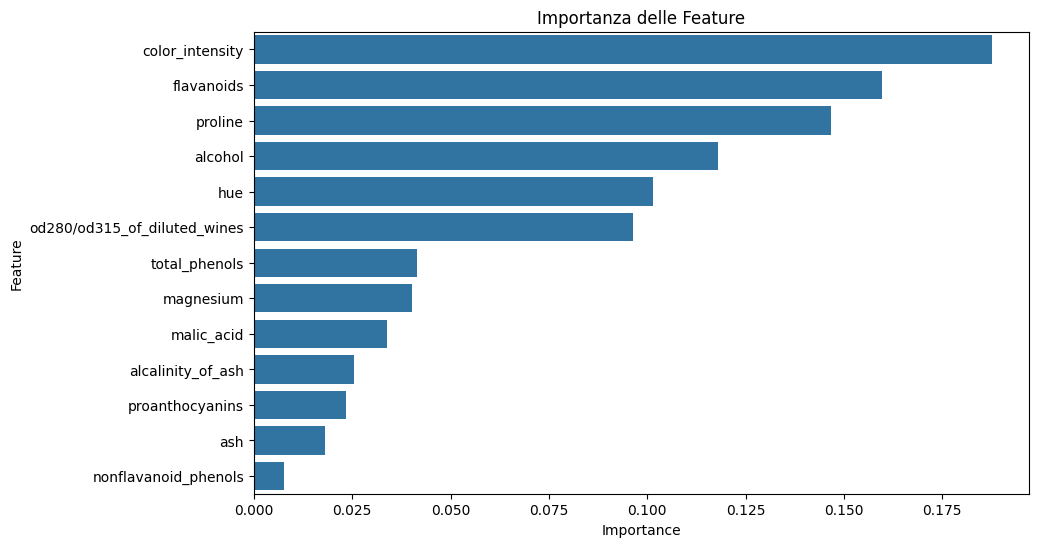

Feature con importanza maggiore di 0.05:
['color_intensity' 'flavanoids' 'proline' 'alcohol' 'hue'
 'od280/od315_of_diluted_wines']


In [18]:
# Inizializza il modello RandomForestClassifier con un seed per la riproducibilità
rf = RandomForestClassifier(random_state=42)

# Allena il modello sui dati di training
rf.fit(X_train, y_train)

# Estrae i valori di importanza associati a ciascuna feature
feature_importances = rf.feature_importances_

# Crea un DataFrame che associa ogni feature alla sua importanza
feature_importance_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': feature_importances
})

# Ordina le feature in base alla loro importanza, in ordine decrescente
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualizza la tabella delle feature con le rispettive importanze
print(feature_importance_df.T.to_string())

# Genera un grafico a barre per rappresentare visivamente l'importanza delle feature
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Importanza delle Feature")
plt.show()

# Seleziona solo le feature con un'importanza superiore a 0.05
important_features = feature_importance_df[feature_importance_df['Importance'] > 0.05]['Feature'].values

# Stampa l'elenco delle feature considerate importanti
print("Feature con importanza maggiore di 0.05:")
print(important_features)

# Filtra il dataset scalato mantenendo solo le feature più rilevanti
X_train_scaled_selected = X_train_scaled[important_features]
X_test_scaled_selected = X_test_scaled[important_features]

## Rieseguo uno spotcheck ma confrontando i due set, quello completo e quello parziale

In [19]:
np.random.seed(0)
# Funzione per eseguire la cross-validation e restituire i risultati
def rapid_spot(X_data_input, y_train):
    """
    Esegue la valutazione dei modelli con cross-validation e restituisce i risultati in un DataFrame.

    Parametri:
    - X_data_input: Un singolo set di dati o una lista di set di dati
    - y_train: Target di addestramento

    Restituisce:
    - Un dizionario contenente DataFrame con i risultati per ciascun set di dati.
    """
    # Se è un singolo dataset, lo trasformiamo in lista
    if not isinstance(X_data_input, list):
        X_data_list = [X_data_input]
    else:
        X_data_list = X_data_input

    modelli = {
        'LogisticRegression': LogisticRegression(),
        'RandomForestClassifier': RandomForestClassifier(n_jobs=-1),
        'KNeighborsClassifier': KNeighborsClassifier(),
        'LinearRegression': LinearRegression()
    }

    risultati_completi = {}

    frame = inspect.currentframe().f_back
    caller_locals = frame.f_locals
    nome_dati = [name for name, value in caller_locals.items() if id(value) in [id(X) for X in X_data_list]]

    # In caso manchino dei nomi (es: lista creata inline), generiamo nomi fallback
    while len(nome_dati) < len(X_data_list):
        nome_dati.append(f"Dataset_{len(nome_dati)+1}")

    for X_dat, nome_dato in zip(X_data_list, nome_dati):
        print(f'\nValutazioni per {nome_dato}:')

        risultati_modelli = []

        for nome_modello, modello in modelli.items():
            seed = 7
            cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

            risultati = cross_val_score(modello, X_dat, y_train, cv=cv)
            risultati_modelli.append(risultati.mean())

            print(f'{nome_modello}: Accuratezza media: {risultati.mean()}')

        risultati_completi[nome_dato] = pd.DataFrame({
            'Modello': modelli.keys(),
            'Accuratezza media': risultati_modelli
        })

    return risultati_completi

# Chiamata della funzione con i dati
risultati_completi = rapid_spot([X_train_scaled, X_train_scaled_selected], y_train) # X_train_scaled_mutual_selected,  X_train_scaled_selected_chi2,

# Mostra le tabelle per ogni set di dati
for nome_dato, tabella in risultati_completi.items():
    print(f'\nTabella dei risultati per {nome_dato}:')
    print(tabella)


Valutazioni per X_train_scaled:
LogisticRegression: Accuratezza media: 0.9785714285714286
RandomForestClassifier: Accuratezza media: 0.9785714285714286
KNeighborsClassifier: Accuratezza media: 0.9504761904761905
LinearRegression: Accuratezza media: 0.8870491080449074

Valutazioni per X_train_scaled_selected:
LogisticRegression: Accuratezza media: 0.9861904761904763
RandomForestClassifier: Accuratezza media: 0.9785714285714286
KNeighborsClassifier: Accuratezza media: 0.9790476190476192
LinearRegression: Accuratezza media: 0.8695496200182136

Tabella dei risultati per X_train_scaled:
                  Modello  Accuratezza media
0      LogisticRegression           0.978571
1  RandomForestClassifier           0.978571
2    KNeighborsClassifier           0.950476
3        LinearRegression           0.887049

Tabella dei risultati per X_train_scaled_selected:
                  Modello  Accuratezza media
0      LogisticRegression           0.986190
1  RandomForestClassifier           0.97857

Dai risultati ottenuti si nota chiaramente come i modelli testati sul set `X_train_scaled` mostrino già un’elevata capacità predittiva. In particolare, sia **Logistic Regression** che **Random Forest Classifier** raggiungono un’accuratezza media del **97.86%**, seguiti dal **KNeighbors Classifier** con circa **95.05%**, e dalla **Linear Regression**, che pur essendo un modello più semplice, ottiene comunque un buon **88.70%**.

Successivamente, è stata effettuata una selezione delle feature per costruire un nuovo set di dati, `X_train_scaled_selected`, con l’obiettivo di semplificare il modello mantenendo o migliorando le performance. I risultati sono interessanti: la **Logistic Regression** migliora ulteriormente raggiungendo un’accuratezza media del **98.62%**, mentre il **KNeighbors Classifier** sale leggermente al **97.90%**. **Random Forest**, invece, mantiene la stessa performance (97.86%), mentre **Linear Regression** cala leggermente, passando a **86.95%**.

Concentrandoci sul confronto tra **Random Forest** e **Linear Regression**, notiamo come i due modelli si comportino in modo diverso rispetto alla selezione delle feature. **Random Forest** si dimostra estremamente stabile: la sua accuratezza rimane invariata anche dopo la rimozione di alcune variabili, a conferma della sua capacità di gestire set di dati complessi e ridondanti senza perdere in efficacia. Questo è uno dei suoi punti di forza principali: è in grado di individuare e sfruttare solo le feature realmente utili durante la fase di costruzione degli alberi, ignorando automaticamente quelle poco informative o collineari.

La **Linear Regression**, invece, risente maggiormente della selezione delle variabili. La leggera perdita di performance può essere dovuta al fatto che alcune delle feature rimosse, pur essendo magari ridondanti, contribuivano in parte a spiegare la variabilità del target. Inoltre, essendo un modello lineare, è più sensibile alla **multicollinearità**, ovvero alla presenza di variabili fortemente correlate tra loro. Questa condizione può alterare l’interpretabilità dei coefficienti e rendere meno stabile la predizione. Al contrario, Random Forest gestisce bene la multicollinearità grazie alla sua struttura non lineare e all’uso di sottoinsiemi casuali di feature per la costruzione degli alberi.

È importante sottolineare che entrambi i modelli stanno performando bene principalmente perché il **dataset di partenza è di alta qualità**. Quando anche un modello semplice come Linear Regression riesce ad avvicinarsi all’accuratezza di modelli più sofisticati, questo è spesso indice di un set di dati ben costruito. In particolare, ciò che rende questo dataset “ottimo” è la **presenza di una forte correlazione tra le feature e il target**, l’assenza di valori mancanti o rumorosi, una buona distribuzione bilanciata tra le classi, e la presenza di variabili davvero informative. In altre parole, le feature spiegano bene il fenomeno che si vuole predire.

In conclusione, la selezione delle feature ha portato benefici soprattutto per la Logistic Regression e il KNN, migliorando o mantenendo le performance con un set più snello. Random Forest ha dimostrato la sua robustezza, mantenendo invariata la sua accuratezza, mentre Linear Regression ha subito una leggera flessione, evidenziando la sua maggiore dipendenza dalla struttura e qualità delle variabili. Tuttavia, il fatto che anche Linear Regression raggiunga valori superiori all'86% dimostra che, più di tutto, è il **dataset stesso a guidare la qualità della predizione**: un set ricco di segnale, ben bilanciato e strutturato è la chiave per ottenere buoni risultati, indipendentemente dal modello utilizzato.

### 8. **Ricerca dei migliori iperparametri**

Una parte cruciale per ottimizzare le performance del modello è la ricerca dei migliori iperparametri. Per questo, confronto il modello addestrato con il set completo di feature e con quello addestrato utilizzando solo le feature selezionate. In particolare, cerco di ottimizzare iperparametri (ad esempio, `n_estimators`, `max_depth`, `min_samples_split`, etc.). L’obiettivo è trovare la combinazione di iperparametri che massimizza la performance del modello.

In [32]:
# Imposta il seme per la riproducibilità dei risultati
np.random.seed(0)

# Definizione dello spazio dei parametri da esplorare per la Random Forest
param_dist = {
    'n_estimators': [50, 100, 150, 200, 250, 300],  # Numero di alberi
    'max_depth': [None, 10, 20, 30, 40, 50],  # Profondità massima degli alberi
    'min_samples_split': [2, 5, 10],  # Minimo numero di campioni per dividere un nodo
    'min_samples_leaf': [1, 2, 4],  # Minimo numero di campioni per un foglio
    'bootstrap': [True, False],  # Usa bootstrap per la selezione dei dati
    'class_weight': [None, 'balanced'],  # Gestione del bilanciamento delle classi
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 1.0, None]  # <- aggiunto
}

# Funzione principale che esegue RandomizedSearchCV con validazione incrociata
def execute_randomized_search_with_cv(X, y, param_dist, n_iter=40, cv=5, n_splits=5, shuffle=True, random_state=42):
    # Inizializzazione del classificatore Random Forest
    rf = RandomForestClassifier(random_state=random_state)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state)

    # Configura la ricerca randomizzata sui parametri
    random_search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=cv,
        n_jobs=-1,  # Usa tutti i core del processore
        verbose=2,  # Aumenta la verbosità per il debug
        random_state=random_state
    )

    # Avvia la ricerca e calcola il tempo di esecuzione
    start_time = time()
    random_search.fit(X, y)
    execution_time = time() - start_time

    # Calcola il tempo in minuti e secondi
    execution_time_minutes = int(execution_time // 60)
    execution_time_seconds = int(execution_time % 60)
    execution_time_str = f"{execution_time_minutes} minuti {execution_time_seconds} secondi" if execution_time_minutes > 0 else f"{execution_time_seconds} secondi"

    # Estrazione dei parametri migliori e della miglior accuratezza della cross-validation
    best_params = random_search.best_params_
    best_cv_accuracy = random_search.best_score_

    # Salva tutti i risultati del CV in un DataFrame
    cv_results_df = pd.DataFrame(random_search.cv_results_)
    cv_results_df = cv_results_df.sort_values(by='mean_test_score', ascending=False)

    # Costruzione del dizionario dei risultati
    model_results = {
        'Best Params': best_params,
        'Best Cross-Validation Accuracy': best_cv_accuracy,
        'Execution Time': execution_time_str,  # Tempo formattato
        'Best Estimator': random_search.best_estimator_,
        'CV Results': cv_results_df  # Aggiunto qui
    }

    # Predizioni tramite validazione incrociata
    y_pred_cv = cross_val_predict(random_search.best_estimator_, X, y, cv=cv)

    # Creazione della matrice di confusione e del report di classificazione
    conf_matrix = confusion_matrix(y, y_pred_cv)
    class_report = classification_report(y, y_pred_cv, zero_division=0, output_dict=True)

    # Costruzione della tabella della matrice di confusione
    tables = []
    if conf_matrix is not None:
        cm = conf_matrix
        title = "Confusion Matrix"

        # Formattazione per la classificazione binaria
        if cm.shape == (2, 2):
            cm_labels = ["AP", "AN"]
            cm_values = [
                [f"{cm[0,0]:.2f} (TP)", f"{cm[0,1]:.2f} (FP)"],
                [f"{cm[1,0]:.2f} (FN)", f"{cm[1,1]:.2f} (TN)"]
            ]
            table = tabulate(cm_values, headers=cm_labels, showindex=["PP", "PN"], tablefmt="grid")
        else:
            # Formattazione per la classificazione multiclasse
            cm_values = [[f"{value:.2f}" for value in row] for row in cm]  # Formatta con due decimali
            table = tabulate(
                cm_values,
                headers=[f"Class {i}" for i in range(cm.shape[1])],
                showindex=[f"True {i}" for i in range(cm.shape[0])],
                tablefmt="grid"
            )

        # Aggiungi un titolo centrato sopra la tabella
        table_with_title = [title.center(len(table.split('\n')[0]))] + table.split('\n')
        tables.append(table_with_title)

    # Combina tutte le tabelle di confusione in un'unica stringa stampabile
    table_strings = []
    if tables:
        max_lines = max(len(table) for table in tables)
        for lines in zip_longest(*tables, fillvalue=""):
            table_strings.append("   ".join(line.ljust(40) for line in lines))

    # Converte il classification report in DataFrame per una visualizzazione più chiara
    class_report_df = pd.DataFrame(class_report).transpose()
    # Applica la formattazione con 2 decimali sui valori numerici
    class_report_df = class_report_df.apply(lambda x: x.apply(lambda v: f"{v:.2f}" if isinstance(v, (int, float)) else v))

    return model_results, class_report_df, table_strings


# Funzione per visualizzare i risultati del RandomizedSearchCV
def display_results(model_results, class_report, tabelle, dataset_name="Dataset"):
    # Estrazione dei risultati principali
    best_params = model_results['Best Params']
    best_cv_accuracy = model_results['Best Cross-Validation Accuracy']
    execution_time = model_results['Execution Time']
    best_estimator = model_results['Best Estimator']
    cv_results = model_results['CV Results']

    # Visualizzazione delle metriche principali
    print(f"\nBest Cross-Validation Accuracy ({dataset_name}): {best_cv_accuracy:.2f}")
    print(f"Execution Time ({dataset_name}): {execution_time}")
    print(f"Best Parameters ({dataset_name}): {best_params}")
    print(f"Best Estimator ({dataset_name}): {best_estimator}\n")

    # Visualizzazione delle top 5 combinazioni di parametri
    print(f"Top 5 combinazioni di parametri ({dataset_name}):")
    print(cv_results[['mean_test_score', 'params']].head(5).to_string(index=False))

    # Visualizzazione del classification report completo
    print(f"\nClassification Report ({dataset_name}):")
    print(class_report)

    # Visualizzazione delle tabelle delle matrici di confusione
    print(f"\nTabelle delle matrici di confusione ({dataset_name}):")
    for table in tabelle:
        print(table)
    print()

# Esecuzione del modello con tutte le feature
model_results_s, class_report_s, tabelle_s = execute_randomized_search_with_cv(X_train_scaled, y_train, param_dist)
display_results(model_results_s, class_report_s, tabelle_s, dataset_name="Tutte le Feature")

# Esecuzione del modello con le feature selezionate
model_results_ss, class_report_ss, tabelle_ss = execute_randomized_search_with_cv(X_train_scaled_selected, y_train, param_dist)
display_results(model_results_ss, class_report_ss, tabelle_ss, dataset_name="Feature Selezionate")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Cross-Validation Accuracy (Tutte le Feature): 0.99
Execution Time (Tutte le Feature): 29 secondi
Best Parameters (Tutte le Feature): {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 40, 'criterion': 'gini', 'class_weight': 'balanced', 'bootstrap': False}
Best Estimator (Tutte le Feature): RandomForestClassifier(bootstrap=False, class_weight='balanced', max_depth=40,
                       max_features='log2', min_samples_leaf=2,
                       n_estimators=200, random_state=42)

Top 5 combinazioni di parametri (Tutte le Feature):
 mean_test_score                                                                                                                                                                             params
        0.993103 {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 40, 'criteri

Ho scelto di utilizzare il **train set completo** con tutte le feature, poiché non ci sono reali motivi per non farlo, né dal punto di vista computazionale né per il rischio di overfitting, anzi è anche leggermente più accurato. Random Forest, infatti, è un modello di ensemble robusto che può gestire bene tutte le variabili senza soffrire di overfitting, anche con un numero elevato di feature. Inoltre, il modello ha mostrato una buona capacità di generalizzazione e non vi sono vantaggi significativi nell'escludere alcune variabili. Pertanto, ho deciso di mantenere tutte le feature per costruire il modello finale. Dopo vari test il numero di iterazioni scelto è n_iter=40 perché oltre a questo numero non si osservano miglioramenti significativi nelle prestazioni, quindi ulteriori iterazioni non avrebbero portato vantaggi concreti.

### 9. **Creazione del modello finale con i migliori parametri**

Per la valutazione finale, utilizzo il test set precedentemente preparato, creado predizioni utilizzando il modello preaddestrato con i dati di addestramento avendo tutte le feature, successivamente valutato i valori predetti confrontandoli con la i target di test per verificarne la performance. Utilizzo le metriche di valutazione (come accuracy, precision, recall, F1-score) per capire quanto bene il modello si comporta. Questo approccio ha dimostrato performance solide sui dati di test.

In [28]:
# Imposta il seed per la riproducibilità dei risultati
np.random.seed(0)

# Utilizza il modello allenato per fare previsioni sul test set
y_pred = model_results_s['Best Estimator'].predict(X_test_scaled)

# Calcola la metrica di accuratezza del modello
accuracy = accuracy_score(y_test, y_pred)

# Calcola la matrice di confusione per valutare i veri positivi/negativi e falsi positivi/negativi
conf_matrix = confusion_matrix(y_test, y_pred)

# Ottiene il classification report con precision, recall e f1-score per ogni classe
class_report = classification_report(y_test, y_pred)

# Stampa delle metriche di valutazione
print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}\n")
print(f"Classification Report:\n{class_report}")

Accuracy: 1.0
Confusion Matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



### Conclusioni dall'analisi dei dati
Dall'analisi dei dati emergono diverse informazioni cruciali per la costruzione e l'ottimizzazione del modello:

1. **Caratteristiche dei dati**: L'esplorazione dei dati evidenzia la presenza di variabili con una forte correlazione tra di loro, il che suggerisce che il modello potrebbe beneficiare della riduzione della dimensionalità o della selezione di feature. Inoltre, sono emerse alcune variabili potenzialmente molto rilevanti per la predizione, mentre altre risultano meno influenti, il che giustifica l’esecuzione di test con selezione delle feature prima dell’addestramento del modello.

2. **Relazioni non lineari**: Le relazioni tra alcune feature e la variabile target sembrano non seguire un andamento lineare. Questo rende il modello **Random Forest** particolarmente adatto, in quanto è in grado di catturare automaticamente relazioni complesse e non lineari, senza la necessità di esplicitarle manualmente.

---

### Perché scelgo il **Random Forest**?

1. **Gestione di dati complessi e non lineari**: Random Forest è un modello di tipo ensemble che costruisce molteplici alberi decisionali e aggrega i risultati. Questo approccio lo rende altamente efficace per rappresentare interazioni complesse tra le feature, che l’analisi esplorativa ha messo in evidenza.

2. **Versatilità su dati numerici e categorici**: Random Forest può gestire sia variabili numeriche che categoriche, senza richiedere una pesante pre-elaborazione (ad esempio codifiche particolari o scaling), rendendolo flessibile ed efficiente su dataset misti.

3. **Robustezza agli outlier**: Essendo un modello basato su più alberi, è intrinsecamente robusto agli outlier, poiché un singolo valore anomalo ha effetto solo su un sottoinsieme di alberi e non su tutto il modello.

4. **Interpretabilità tramite importanza delle feature**: Pur non essendo interpretabile quanto modelli lineari, Random Forest consente comunque l’analisi della rilevanza delle variabili tramite l’attributo `.feature_importances_`, offrendo informazioni utili sulle variabili più influenti.

---

### Perché uso **RandomizedSearchCV**?

1. **Efficienza in spazi iperparametrici ampi**: RandomizedSearchCV è ideale quando ci sono molti iperparametri da esplorare. Invece di testare ogni combinazione possibile come GridSearchCV, RandomizedSearch esegue un campionamento casuale all'interno dello spazio definito, ottenendo spesso buoni risultati con un numero significativamente ridotto di combinazioni testate.

2. **Rapidità e flessibilità**: RandomizedSearch permette di controllare il tempo di esecuzione tramite il parametro `n_iter`, rendendola una scelta efficace per modelli con molti parametri (come Random Forest), in cui una Grid Search completa potrebbe risultare troppo costosa. Inoltre, consente di identificare combinazioni di parametri promettenti anche in spazi molto vasti, che altrimenti richiederebbero risorse elevate per essere esplorati completamente.

---

### Perché ho scelto quei **valori e intervalli**?

1. **`n_estimators`**: Questo parametro controlla il numero di alberi nella foresta. Un numero troppo basso potrebbe non essere sufficiente a garantire la stabilità del modello, mentre uno troppo elevato aumenterebbe inutilmente il tempo di addestramento. L’intervallo scelto (tra 50 e 300) rappresenta un buon compromesso tra stabilità ed efficienza computazionale.

2. **`max_depth`**: Impostare una profondità massima per ogni albero aiuta a prevenire l’overfitting. Ho testato valori da `None` (cioè profondità illimitata) a profondità limitate (10, 20...), per analizzare l’effetto della complessità sulla generalizzazione del modello.

3. **`min_samples_split` e `min_samples_leaf`**: Questi parametri influenzano la crescita degli alberi. Se impostati troppo bassi, possono portare a modelli eccessivamente complessi. L’intervallo selezionato permette di esplorare diverse strategie di crescita controllata degli alberi.

4. **`bootstrap`**: Essendo il bootstrap un elemento chiave del funzionamento dei Random Forest, è utile confrontare modelli costruiti con e senza campionamento con sostituzione, per valutare se questo influisce significativamente sulle prestazioni.

### Cosa significa che i valori ottimali degli iperparametri sono all'estremo dell'intervallo scelto?

1. **Necessità di espandere l’intervallo di ricerca**: Se i valori ottimali sono ai limiti massimi o minimi, è possibile che esistano combinazioni migliori al di fuori dell’intervallo testato. In questo caso, conviene ampliare la ricerca per esplorare nuove possibilità oppure restringerla intorno ai valori trovati per una regolazione più fine.

2. **Bilanciamento tra complessità e costi computazionali**: Parametri estremi possono indicare che il modello beneficia di una maggiore complessità, ma è fondamentale valutare se il teorico miglioramento delle prestazioni giustifica il maggiore tempo di calcolo richiesto.

### Conclusione

- Il modello **Random Forest** è stato scelto per la sua robustezza, versatilità e capacità di modellare relazioni non lineari.  
- L’utilizzo di **RandomizedSearchCV** è motivato dalla necessità di esplorare in modo efficiente uno spazio iperparametrico ampio, con un controllo sul costo computazionale.  
- Gli intervalli di ricerca sono stati scelti con attenzione in base alle caratteristiche del dataset e, in presenza di valori ottimali agli estremi, sarà opportuno considerare l'espansione o la rifinitura dell'intervallo di ricerca per migliorare ulteriormente il modello.